# Notebook 03 — LP Benchmark

Builds the discrete transition matrix and solves the LP formulation from §3.1–3.2 of Löhndorf & Minner (2009).

**Goals:**
- Construct the truncated discrete probability distributions $P_Y^d$ and $P_P^d$ (eqs. 15–16).
- Assemble and solve the LP (eqs. 19–20).
- Visualise the optimal discrete policy as contour plots, replicating Figure 2a and 3a of the paper.

In [2]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from stochastic import StochasticParams
from environment import EnvParams
from transition_matrix import discrete_supply_probs, discrete_price_probs
from lp_benchmark import solve_lp, lp_policy_fn, evaluate_policy

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Discrete probability distributions

Verify the truncated conditional probabilities $P_Y^d(y'|y)$ and $P_P^d(p'|p, y', y)$ sum to 1.

In [3]:
params = StochasticParams(mu_Y=5.0, sigma_Y=2.0, theta_Y=0.5,
                          mu_P=5.0, sigma_P=2.0, theta_P=0.5, rho=-0.5)
Y_grid = np.arange(0, 11, dtype=float)  # {0, 1, ..., 10}
P_grid = np.arange(0, 11, dtype=float)

# Check supply probabilities for y=5
py = discrete_supply_probs(5, Y_grid, params)
print(f"P_Y^d(y'|y=5):  sum={py.sum():.6f}")
print("  y':", Y_grid.astype(int).tolist())
print("  P: ", np.round(py, 4).tolist())

# Check price probabilities for p=5, y'=4, y=5
pp = discrete_price_probs(5, 4, 5, P_grid, params)
print(f"\nP_P^d(p'|p=5, y'=4, y=5):  sum={pp.sum():.6f}")
print("  p':", P_grid.astype(int).tolist())
print("  P: ", np.round(pp, 4).tolist())

P_Y^d(y'|y=5):  sum=1.000000
  y': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  P:  [0.0047, 0.017, 0.0528, 0.1188, 0.1932, 0.2272, 0.1932, 0.1188, 0.0528, 0.017, 0.0047]

P_P^d(p'|p=5, y'=4, y=5):  sum=1.000000
  p': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  P:  [0.0004, 0.0034, 0.0189, 0.0685, 0.1613, 0.2475, 0.2475, 0.1613, 0.0685, 0.0189, 0.0038]


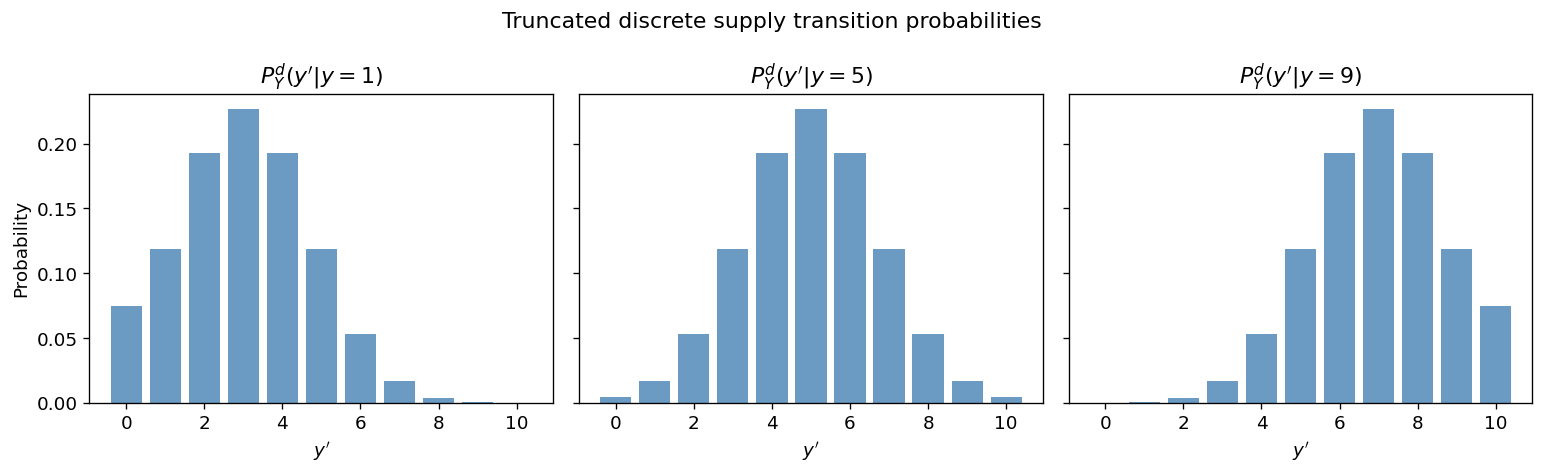

In [4]:
# Visualise conditional supply distribution for various y
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, y_curr in zip(axes, [1, 5, 9]):
    py = discrete_supply_probs(y_curr, Y_grid, params)
    ax.bar(Y_grid, py, color='steelblue', alpha=0.8)
    ax.set_xlabel("$y'$")
    ax.set_title(f'$P_Y^d(y\'|y={y_curr})$')
axes[0].set_ylabel('Probability')
plt.suptitle('Truncated discrete supply transition probabilities')
plt.tight_layout()
plt.show()

## 2. Solve the LP

Use the small discrete grid $\{0,...,10\}$ for $Y$, $P$, $G$ and $X$ as in the paper.
**Warning:** this takes ~1–2 minutes for the full 11×11×5 grid.

In [5]:
env = EnvParams(C=4.0, eta_plus=1.0, eta_minus=1.0, u=1.0, o=0.0, gamma=0.9)

Y_grid = np.arange(0, 11, dtype=float)
P_grid = np.arange(0, 11, dtype=float)
G_grid = np.arange(0, int(env.C) + 1, dtype=float)  # {0, 1, 2, 3, 4}
X_grid = np.arange(0, 11, dtype=float)

result = solve_lp(Y_grid, P_grid, G_grid, X_grid, params, env)
print("LP solved. Value function stats:")
print(f"  min V = {result['V'].min():.2f},  max V = {result['V'].max():.2f},  mean V = {result['V'].mean():.2f}")

Building transition matrix...
Assembling LP...
Solving LP (605 variables, 6655 constraints)...
LP solved. Value function stats:
  min V = 188.03,  max V = 294.74,  mean V = 227.96


## 3. Policy contour plots (replicating Figures 2a and 3a)

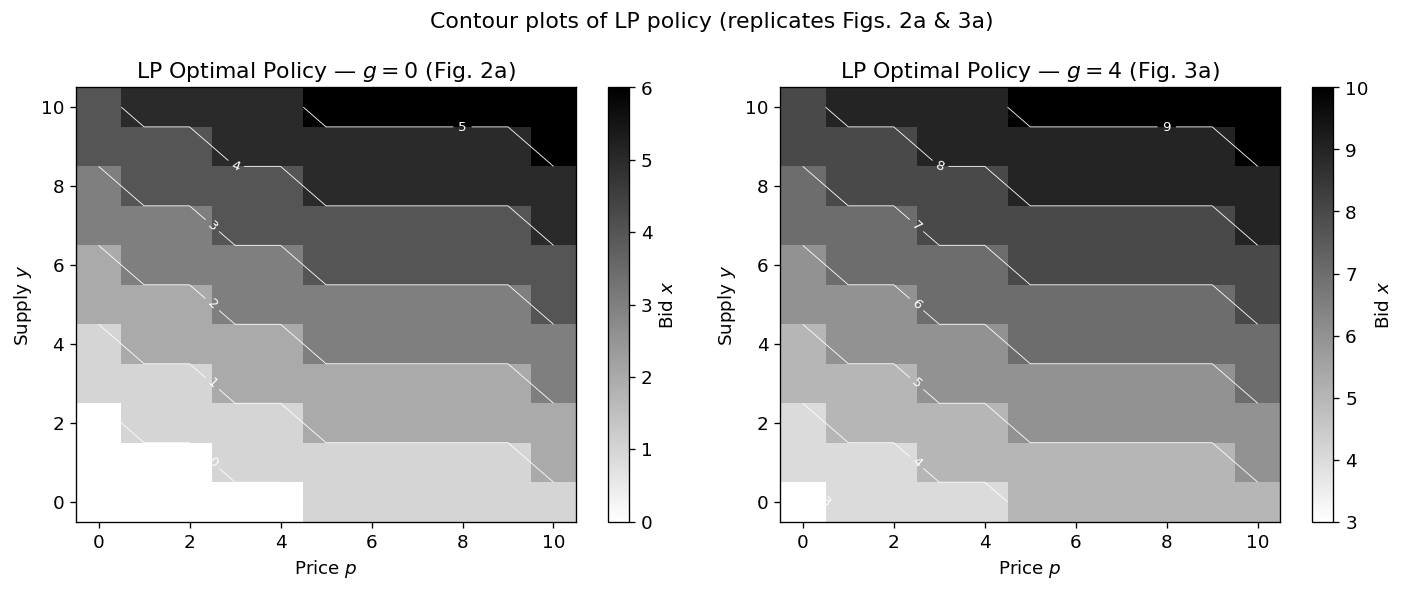

In [6]:
nY, nP, nG = len(Y_grid), len(P_grid), len(G_grid)

def state_idx(iy, ip, ig):
    return iy * nP * nG + ip * nG + ig

def policy_grid(g_fixed):
    ig = int(g_fixed)
    bids = np.zeros((nY, nP))
    for iy in range(nY):
        for ip in range(nP):
            s = state_idx(iy, ip, ig)
            bids[iy, ip] = X_grid[result['policy'][s]]
    return bids

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, g_fixed, title in zip(axes, [0, 4], ['$g=0$ (Fig. 2a)', '$g=4$ (Fig. 3a)']):
    bids = policy_grid(g_fixed)
    # plot as filled contour (LP policy is discrete, so pcolormesh is more faithful)
    im = ax.pcolormesh(P_grid, Y_grid, bids, cmap='gray_r', shading='nearest')
    cs = ax.contour(P_grid, Y_grid, bids, levels=np.arange(0.5, 10.5), colors='white', linewidths=0.5)
    ax.clabel(cs, inline=True, fontsize=8, fmt='%d')
    plt.colorbar(im, ax=ax, label='Bid $x$')
    ax.set_xlabel('Price $p$')
    ax.set_ylabel('Supply $y$')
    ax.set_title(f'LP Optimal Policy — {title}')

plt.suptitle('Contour plots of LP policy (replicates Figs. 2a & 3a)')
plt.tight_layout()
plt.show()

## 4. Value function

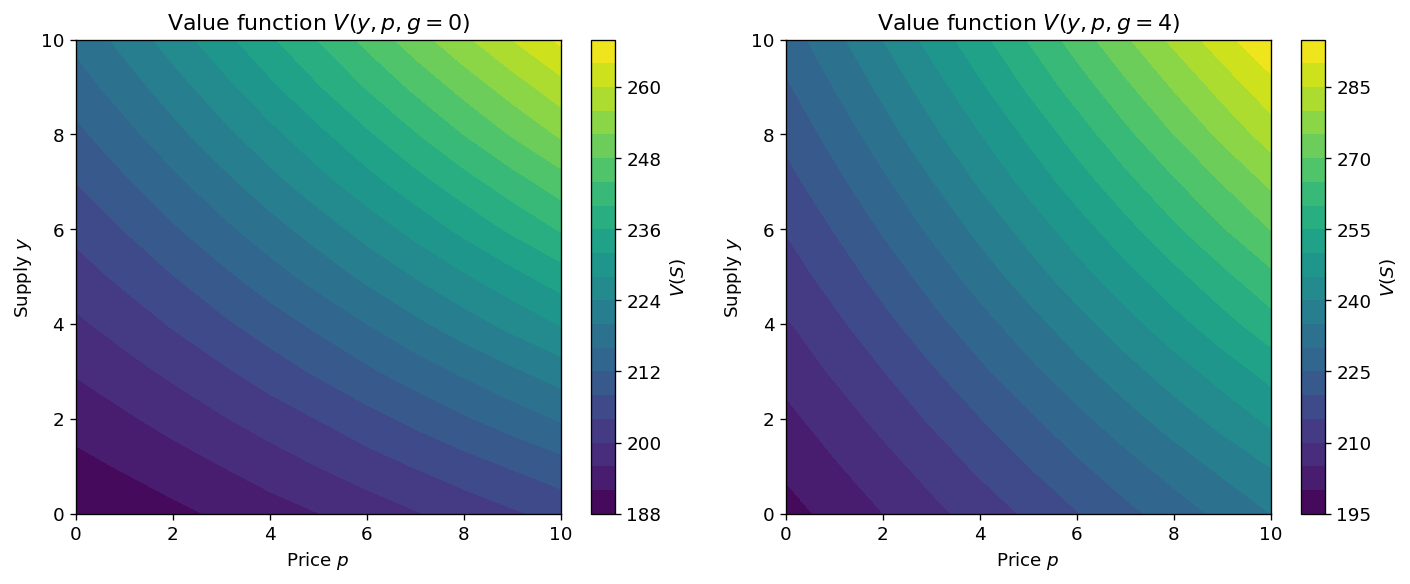

In [7]:
def value_grid(g_fixed):
    ig = int(g_fixed)
    vals = np.zeros((nY, nP))
    for iy in range(nY):
        for ip in range(nP):
            s = state_idx(iy, ip, ig)
            vals[iy, ip] = result['V'][s]
    return vals

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, g_fixed in zip(axes, [0, 4]):
    V_grid = value_grid(g_fixed)
    im = ax.contourf(P_grid, Y_grid, V_grid, levels=20, cmap='viridis')
    plt.colorbar(im, ax=ax, label='$V(S)$')
    ax.set_xlabel('Price $p$')
    ax.set_ylabel('Supply $y$')
    ax.set_title(f'Value function $V(y, p, g={g_fixed})$')

plt.tight_layout()
plt.show()

## 5. Simulated reward of the LP policy

In [8]:
policy_fn = lp_policy_fn(result)
discounted_reward = evaluate_policy(policy_fn, env, params, T_eval=10_000, seed=42)
print(f"LP policy — simulated discounted reward: {discounted_reward:.2f}")
print("(Paper reports mean reward ≈ 19.94 for LP over 90 configurations)")

LP policy — simulated discounted reward: 213.50
(Paper reports mean reward ≈ 19.94 for LP over 90 configurations)
